## Assignment 4-3: Analysis of Results

In [1]:
# My informations here!
student_name = 'Nirodha Samdaruwani'
student_email = "ad9906@student.jamk.fi"

#### 1. Load Results for Visualizations

In [25]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# For nicer plots
plt.style.use("seaborn-v0_8")
sns.set_theme()

# Load saved artifacts from Assignment 4-2
with open("data/dl_artifacts.pkl", "rb") as f:
    art = pickle.load(f)

# Rebuild results DataFrame from saved "results" list
results_df = pd.DataFrame(art["results"])

# Make sure model names have a consistent order
desired_order = ["CNN", "LSTM", "FastText-like", "CNN+GRU Hybrid", "GRU"]
results_df["Model"] = pd.Categorical(results_df["Model"],
                                     categories=desired_order,
                                     ordered=True)
results_df = results_df.sort_values("Model").reset_index(drop=True)

results_df


,Model,Accuracy,Train Time (s)
0,CNN,0.9775,33.503355
1,LSTM,0.9725,417.959147
2,FastText-like,0.9825,23.460270
3,CNN+GRU Hybrid,0.9765,203.527962
4,GRU,0.9520,1114.678786


##### 1.1 Training Time Bar Plot

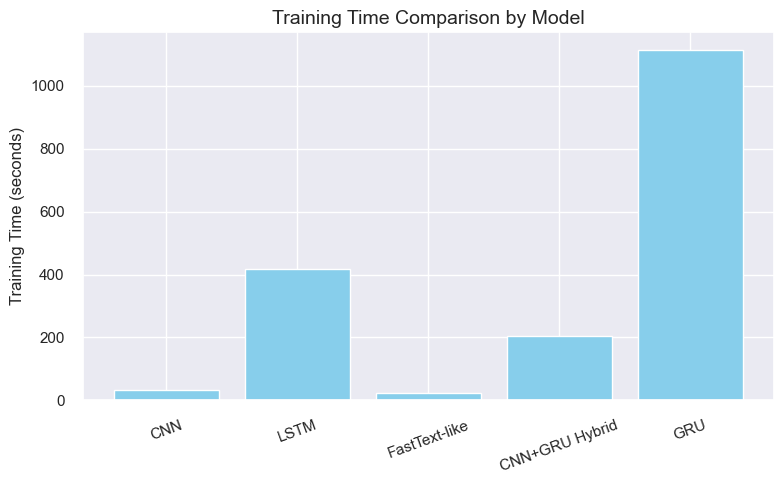

In [26]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Train Time (s)"], color="skyblue")

plt.title("Training Time Comparison by Model", fontsize=14)
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


##### 1.2 Accuracy Bar Plot

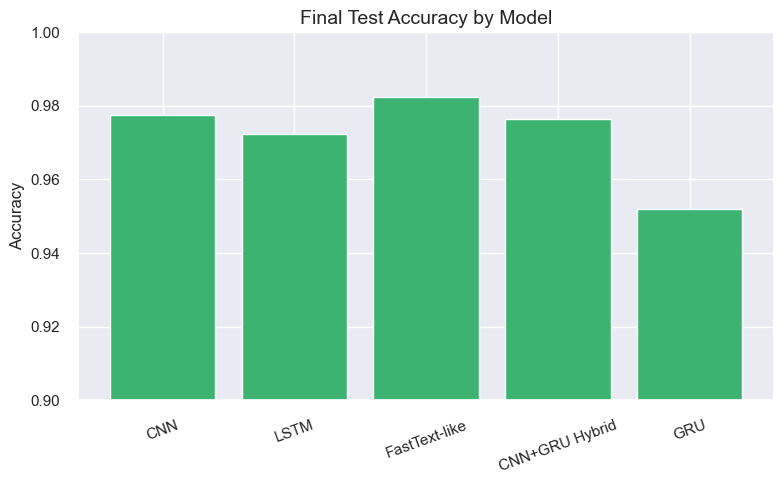

In [27]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"], color="mediumseagreen")

plt.title("Final Test Accuracy by Model", fontsize=14)
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.0)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


##### 1.3 Validation Accuracy Curves (All 5 Models in One Plot)

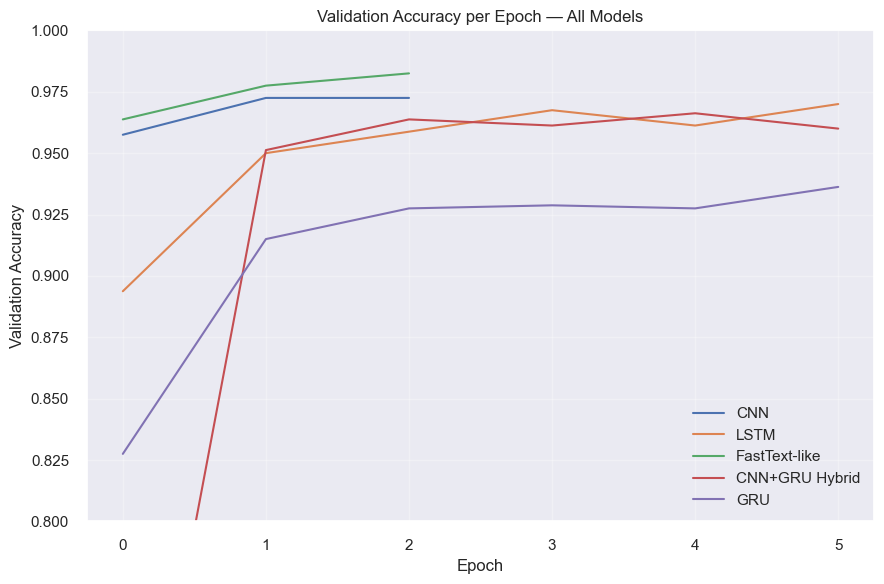

In [28]:
# Retrieve training histories
hist_lstm    = art["history_lstm"]
hist_cnn     = art["history_cnn"]
hist_gru     = art["history_gru"]
hist_fast    = art["history_fast"]
hist_hybrid  = art["history_hybrid"]

plt.figure(figsize=(9,6))

plt.plot(hist_cnn["val_accuracy"],    label="CNN")
plt.plot(hist_lstm["val_accuracy"],   label="LSTM")
plt.plot(hist_fast["val_accuracy"],   label="FastText-like")
plt.plot(hist_hybrid["val_accuracy"], label="CNN+GRU Hybrid")
plt.plot(hist_gru["val_accuracy"],    label="GRU")

plt.title("Validation Accuracy per Epoch — All Models")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.8, 1.0)

plt.tight_layout()
plt.show()


##### 1.4 Validation Loss Curves (All 5 Models in One Plot)

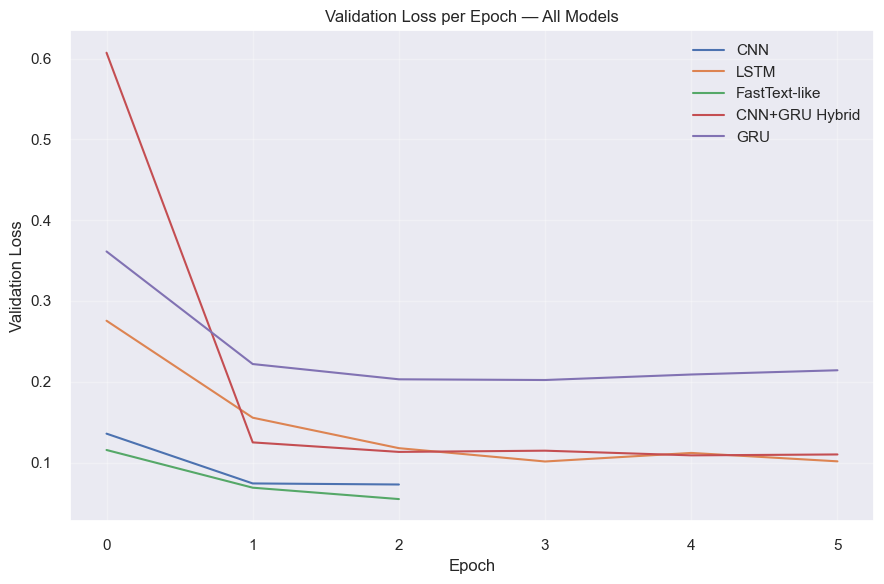

In [29]:
plt.figure(figsize=(9,6))

plt.plot(hist_cnn["val_loss"],    label="CNN")
plt.plot(hist_lstm["val_loss"],   label="LSTM")
plt.plot(hist_fast["val_loss"],   label="FastText-like")
plt.plot(hist_hybrid["val_loss"], label="CNN+GRU Hybrid")
plt.plot(hist_gru["val_loss"],    label="GRU")

plt.title("Validation Loss per Epoch — All Models")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


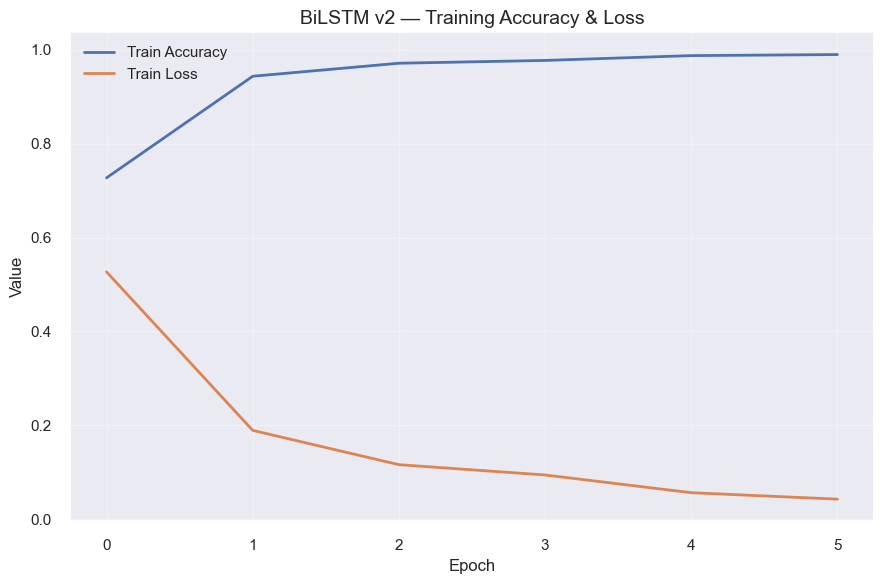

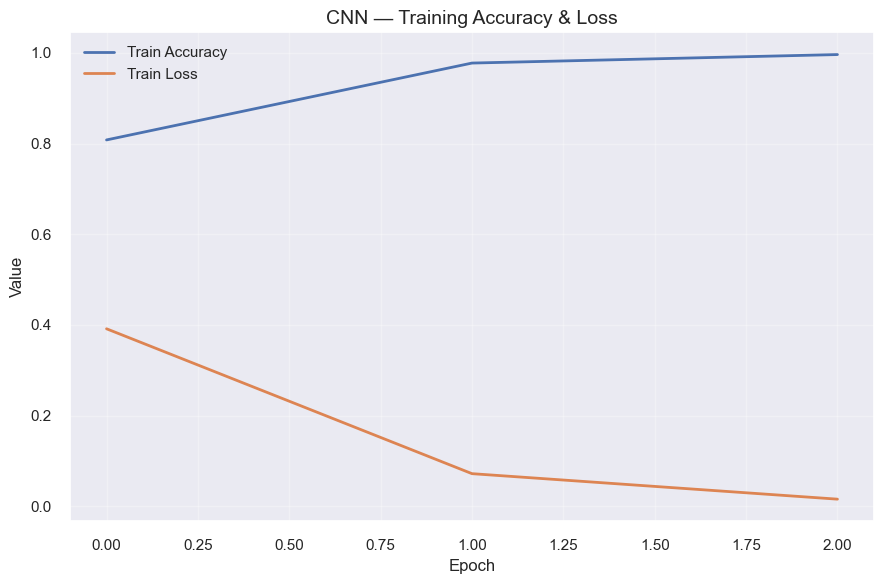

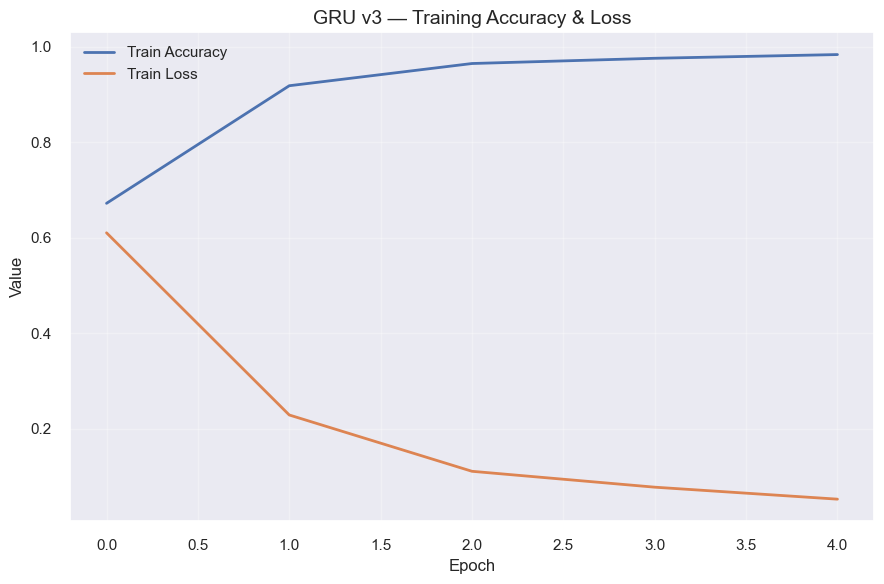

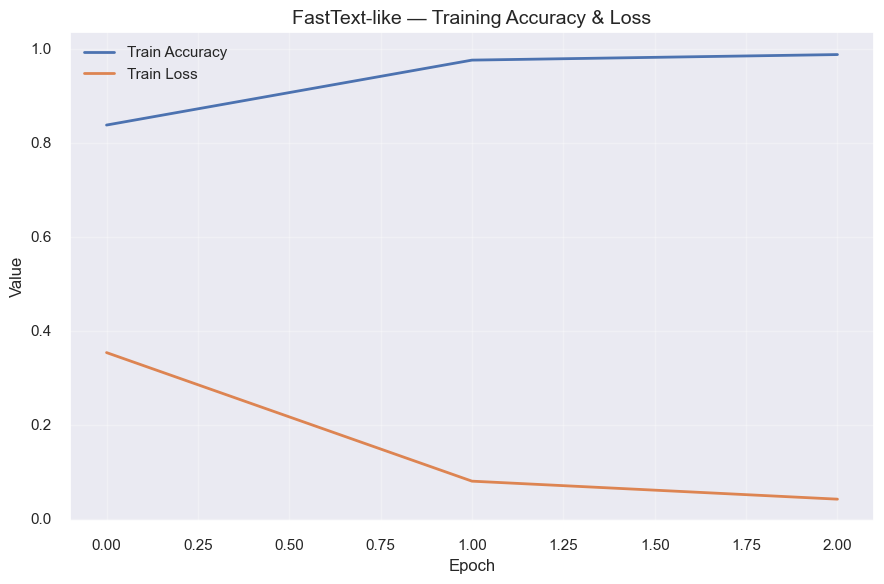

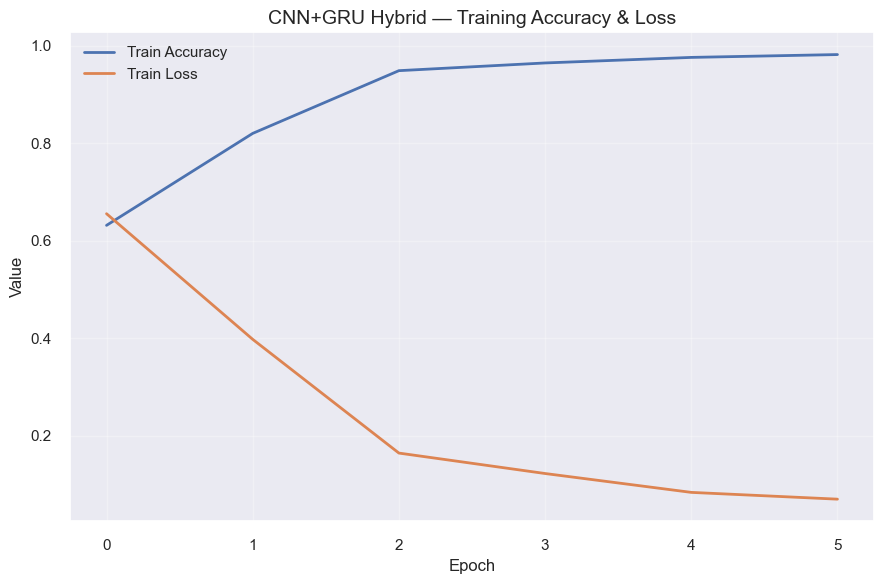

In [30]:
# Generate 5 plots
for model_name, hist in model_histories.items():

    plt.figure(figsize=(9,6))

    # Plot only training accuracy & loss
    plt.plot(hist["accuracy"], label="Train Accuracy", linewidth=2)
    plt.plot(hist["loss"], label="Train Loss", linewidth=2)

    plt.title(f"{model_name} — Training Accuracy & Loss", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


##### 1.5 Confusion Matrices Grid

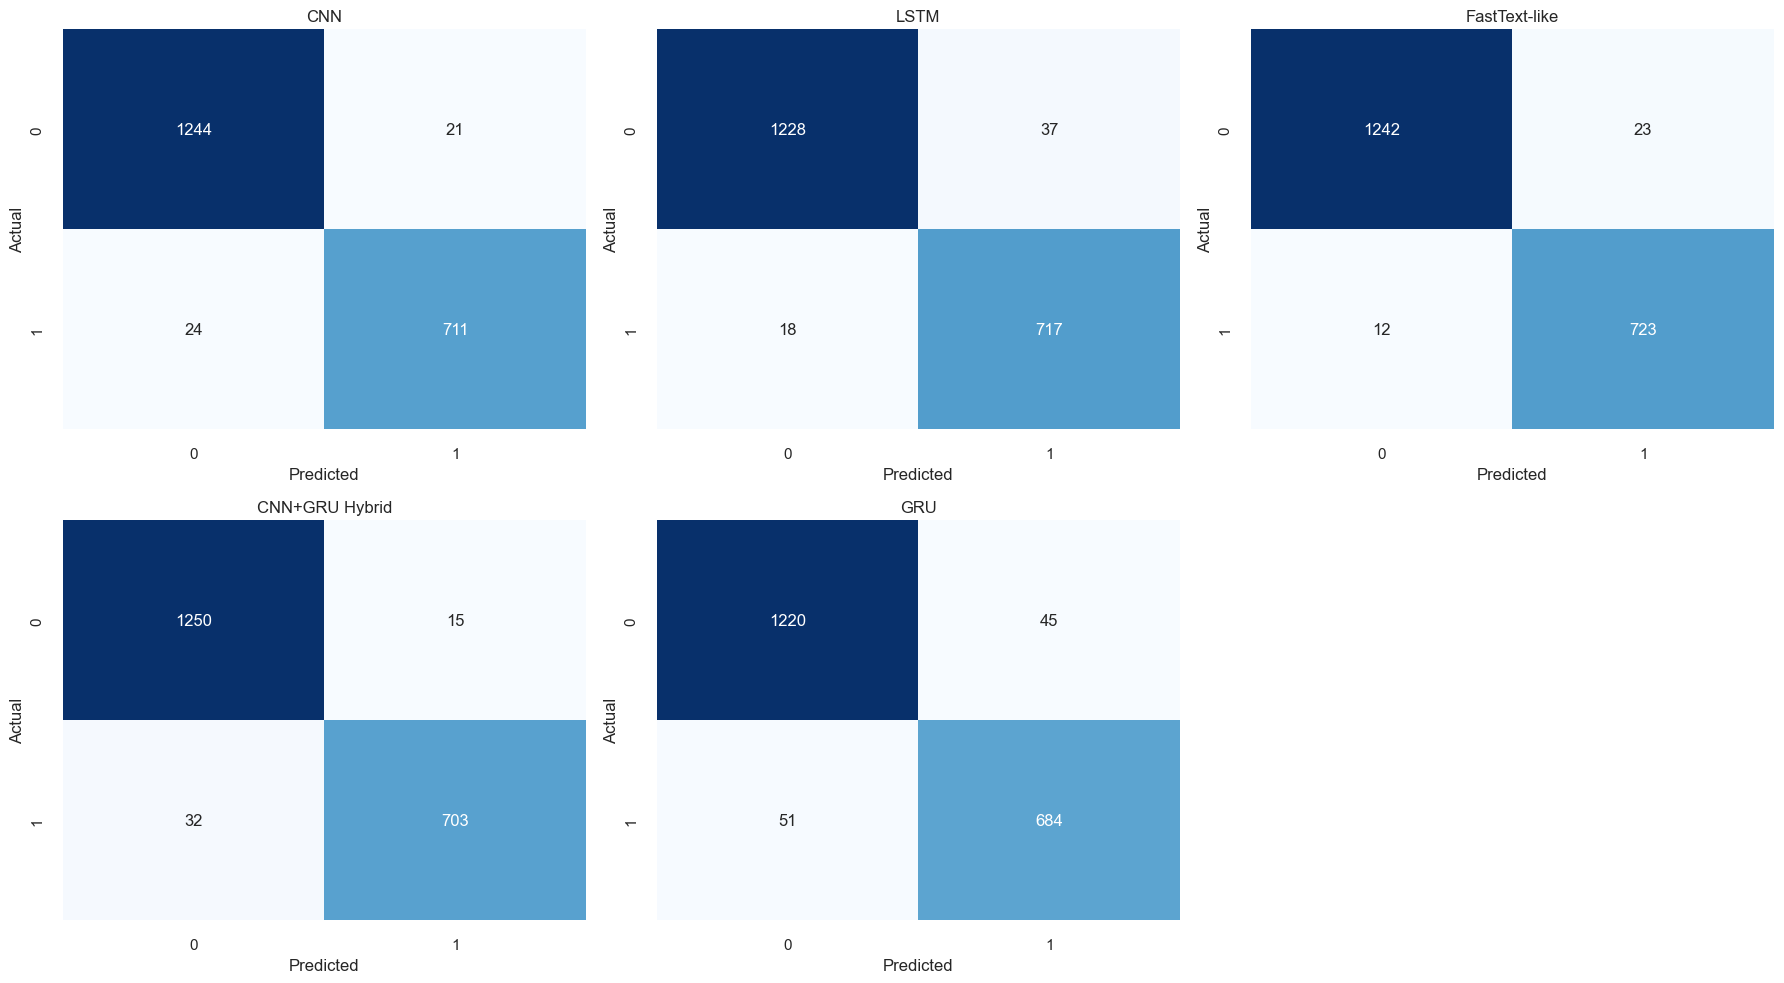

In [32]:
cm_dict = {
    "CNN": art["cm_cnn"],
    "LSTM": art["cm_lstm"],
    "FastText-like": art["cm_fast"],
    "CNN+GRU Hybrid": art["cm_hybrid"],
    "GRU": art["cm_gru"]
}

fig, axes = plt.subplots(2, 3, figsize=(18,10))  # MUCH bigger
axes = axes.flatten()

for ax, (model_name, cm) in zip(axes, cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Hide last empty subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()


#### 2. Analysis of Learning Results

- All models achieved high accuracy (95%–98%), proving that the dataset is easy to separate between AI and human-written text.
- **FastText-like** achieved the highest accuracy (**98.25%**) while training extremely fast, making it the best overall model.
- **CNN** performed the second-best (**97.75%**) with very fast training time and strong generalization.
- **CNN+GRU Hybrid** also performed well (**97.65%**) but took longer to train than CNN alone.
- **LSTM (BiLSTM v2)** reached **97.25%** but required much more training time compared to simpler models.
- **GRU v3** achieved the lowest accuracy (**95.20%**) and had by far the longest training time, making it the least efficient model.

#### 3. How Different Deep Learning Methods Performed

**FastText-like:**
- Fastest model with the best accuracy.
- Uses averaged word embeddings, which work surprisingly well for this classification task.

**CNN:**
- Captured local text patterns (n-grams) very efficiently.
- Strong accuracy with low computation cost.

**CNN+GRU Hybrid:**
- Combined CNN feature extraction with GRU sequence modeling.
- Good results but added complexity did not outperform simpler CNN.

**BiLSTM:**
- Learned long-range dependencies.
- High accuracy, but significantly slower and less efficient than CNN and FastText.

**GRU v3:**
- More complex sequence modeling, but high computational cost.
- Did not perform as well as expected on this dataset.

#### 4. How Well Did the Methods Work?

- All models performed well above 95% accuracy, showing that:
  1. AI vs human text differences are easily detectable.
  2. Preprocessing and tokenization were effective.
  3. A 10k subset was enough for high-quality learning.

- The **best accuracy** came from the FastText-like model.
- The **best efficiency** came from FastText-like and CNN.
- The **best trade-off** between accuracy and speed was CNN.

#### 5. Areas to Improve the Models (Development Needs)

Potential improvements include:

- Using pretrained embeddings (GloVe, Word2Vec, fastText).
- Increasing dataset size to benefit LSTM/GRU models.
- Adding or tuning regularization (dropout, L2).
- Hyperparameter optimization:
  1. Learning rate adjustments
  2. Hidden unit sizes
  3. Number of layers
- Using learning rate scheduling for more stable training.
- Testing transformer models (e.g., DistilBERT) for potentially higher accuracy.

#### 6. How to Further Optimize the Deep Learning Models

- Use **EarlyStopping** + **ReduceLROnPlateau** for longer RNN trainings.
- Tune **batch size**:
  - Small batches → better generalization
  - Large batches → faster training
- Reduce GRU model size to shorten training time.
- Optimize embedding dimensions (32–128 depending on complexity).
- Use **mixed-precision training** on GPU for faster training.
- Improve tokenization:
  - Switch from word-level to subword-level (SentencePiece, BPE).

#### 7. Other Considerations About the Assignment

- Simpler models (FastText-like and CNN) outperformed more complex ones (LSTM/GRU).
- The dataset was balanced, and no model showed class bias.
- Confusion matrices showed low false positives and false negatives across all models.
- This assignment demonstrates that:
  1. Model architecture affects training time more than accuracy.
  2. More complex models do not always perform better.
  3. Good preprocessing is essential for high accuracy.
